In [69]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain.messages import RemoveMessage, HumanMessage

In [70]:
load_dotenv()

True

In [71]:
model = ChatNVIDIA(model = 'openai/gpt-oss-20b')

In [72]:
class ChatState(MessagesState):
    summary : str

In [73]:
def chat_node(state: ChatState):
    messages = []
    
    if state.get('summary'):
        messages.append({
            'role':'system',
            'content':f"Conversation Summary: \n{state['summary']}"
        })
        
    messages.extend(state['messages'])
    
    print(messages)
    
    response = model.invoke(messages)
    return {'messages':[response]}

In [74]:
def summarize_conversation(state: ChatState):
    
    existing_summary = state.get('summary')
    
    if existing_summary:
        prompt = f"""Existing Summary : \n\n {existing_summary}
        Extend the existing conversation using the messages above."""
    else:
        prompt = 'Generate the summary of the above messages conversation.'
        
    messages_for_summary = state['messages'] + [HumanMessage(content = prompt)]
    
    response = model.invoke(messages_for_summary)
    
    # Keep only last 2 messages as verbatim
    messages_to_delete = state['messages'][:-2]
    
    return {
        'summary':response.content,
        'messages':[RemoveMessage(id = m.id) for m in messages_to_delete]
    }

In [75]:
def should_summarize(state: ChatState):
    return len(state['messages']) > 6

In [76]:
builder = StateGraph(ChatState)

builder.add_node('chat',chat_node)
builder.add_node('summarize',summarize_conversation)

builder.add_edge(START,'chat')

builder.add_conditional_edges(
    'chat',
    should_summarize,
    {
        True: 'summarize',
        False: '__end__'
    }
)

builder.add_edge('summarize','__end__')

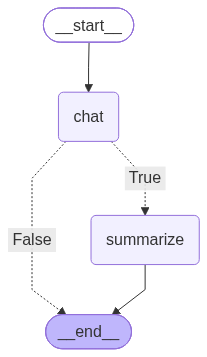

In [77]:
graph = builder.compile(checkpointer = InMemorySaver())
graph

In [78]:
config = {'configurable':{'thread_id':'t1'}}

In [79]:
# Gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print('\n---STATE---')
    print('Summary: ',vals.get('summary'))
    print('Num messages: ',len(vals.get('messages',[])))
    print('Messages: ')
    for m in vals.get('messages',[]):
        print('-',type(m).__name__,':',m.content[:80])

In [80]:
out = graph.invoke({'messages':[HumanMessage(content = 'Quantum Physics')],'summary':''},config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='30d72b6b-50e2-4c6e-b1bf-e69e209aee75')]
{'messages': [HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='30d72b6b-50e2-4c6e-b1bf-e69e209aee75'), AIMessage(content='## Quantum Physics in a Nutshell\n\nQuantum physics (or *quantum mechanics*) is the branch of physics that describes the behavior of matter and energy at the smallest scales—atoms, nuclei, sub‑nuclear particles, and even photons. It revolutionized our view of the physical world and underpins much of modern technology. Below is a concise yet comprehensive guide, covering core concepts, key experiments, mathematical tools, and practical applications.\n\n---\n\n### 1. Historical Milestones\n\n| Year | Discovery / Development | Significance |\n|------|--------------------------|--------------|\n| **1900** | Planck introduces energy quanta (E = hν) | Sets the stage for quantum theory |\n| **1905** | Einste

In [81]:
out = graph.invoke({'messages':[HumanMessage(content = 'How is Albert Einstein related?')]},config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='30d72b6b-50e2-4c6e-b1bf-e69e209aee75'), AIMessage(content='## Quantum Physics in a Nutshell\n\nQuantum physics (or *quantum mechanics*) is the branch of physics that describes the behavior of matter and energy at the smallest scales—atoms, nuclei, sub‑nuclear particles, and even photons. It revolutionized our view of the physical world and underpins much of modern technology. Below is a concise yet comprehensive guide, covering core concepts, key experiments, mathematical tools, and practical applications.\n\n---\n\n### 1. Historical Milestones\n\n| Year | Discovery / Development | Significance |\n|------|--------------------------|--------------|\n| **1900** | Planck introduces energy quanta (E = hν) | Sets the stage for quantum theory |\n| **1905** | Einstein explains the photoelectric effect, introduces the photon | Confirms light’s particle aspect |\n| **1909** | Compton scattering demonstrates

In [82]:
out = graph.invoke({'messages':[HumanMessage(content = "What are some of Einstein's famous works?")]},config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='30d72b6b-50e2-4c6e-b1bf-e69e209aee75'), AIMessage(content='## Quantum Physics in a Nutshell\n\nQuantum physics (or *quantum mechanics*) is the branch of physics that describes the behavior of matter and energy at the smallest scales—atoms, nuclei, sub‑nuclear particles, and even photons. It revolutionized our view of the physical world and underpins much of modern technology. Below is a concise yet comprehensive guide, covering core concepts, key experiments, mathematical tools, and practical applications.\n\n---\n\n### 1. Historical Milestones\n\n| Year | Discovery / Development | Significance |\n|------|--------------------------|--------------|\n| **1900** | Planck introduces energy quanta (E = hν) | Sets the stage for quantum theory |\n| **1905** | Einstein explains the photoelectric effect, introduces the photon | Confirms light’s particle aspect |\n| **1909** | Compton scattering demonstrates

In [83]:
out = graph.invoke({'messages':[HumanMessage(content = "Explain Special Theory of Relativity")]},config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='30d72b6b-50e2-4c6e-b1bf-e69e209aee75'), AIMessage(content='## Quantum Physics in a Nutshell\n\nQuantum physics (or *quantum mechanics*) is the branch of physics that describes the behavior of matter and energy at the smallest scales—atoms, nuclei, sub‑nuclear particles, and even photons. It revolutionized our view of the physical world and underpins much of modern technology. Below is a concise yet comprehensive guide, covering core concepts, key experiments, mathematical tools, and practical applications.\n\n---\n\n### 1. Historical Milestones\n\n| Year | Discovery / Development | Significance |\n|------|--------------------------|--------------|\n| **1900** | Planck introduces energy quanta (E = hν) | Sets the stage for quantum theory |\n| **1905** | Einstein explains the photoelectric effect, introduces the photon | Confirms light’s particle aspect |\n| **1909** | Compton scattering demonstrates